# Analiza lige NBA po sezonah 2016–2026

Ta zvezek je analitični del projektne naloge pri predmetu Uvod v programiranje. Podatke o ekipah in igralcih lige NBA je s spletne strani Basketball-Reference zajel program v datotekah `pridobi.py`, `izlusci.py`, `shrani.py` in `main.py`. V zvezku jih preberem iz CSV datotek in poskušam odgovoriti na vprašanja o tem, kako se je liga spreminjala, katere ekipe so bile uspešne in kdo so njeni najpomembnejši igralci.

## Kazalo vprašanj

**A. Kako se je liga spreminjala skozi čas**

1. Kako se je spremenila igra (trojke po sezonah)?
2. Ali so igralci v ligi starejši?
3. Kolikšen delež igralcev ni rojen v ZDA?

**B. Ekipe**

4. Katere ekipe so najuspešnejše?
5. Katere sezone ekip so bile najboljše?
6. Kaj loči uspešne ekipe?

**C. Igralci**

7. Kdo so najboljši točkovalci?
8. Kdo je dosegel največ točk, skokov in asistenc?
9. Ali pozicija vpliva na skoke in asistence?
10. Kako visoki so igralci?
11. Iz katerih fakultet prihajajo igralci?

## Podatki

Podatki so razdeljeni v štiri povezane tabele (CSV datoteke v mapi `podatki`):

| Tabela | Kaj vsebuje |
|---|---|
| `ekipe` | ekipa in sezona: zmage, porazi, točke in prejete točke na tekmo |
| `igralci` | podatki o igralcu, ki se ne spreminjajo: datum rojstva, država, fakulteta |
| `nastopi` | igralec v ekipi v določeni sezoni: pozicija, višina, teža, izkušnje |
| `statistika` | povprečna statistika igralca na tekmo, ločeno za redni del sezone in končnico |

Tabele so povezane z oznako igralca (`id_igralca`) in z oznako ekipe in sezone (`kratica`, `leto`). Leto pomeni leto, v katerem se sezona konča, torej je 2026 sezona 2025/26.

Opombe, ki jih je treba upoštevati pri branju rezultatov:

- igralec, ki je bil v sezoni zamenjan, ima za vsako ekipo svojo vrstico,
- statistika na tekmo je na strani zaokrožena na eno decimalko, zato so vsote, izračunane iz nje, približne,
- sezoni 2020 in 2021 sta bili krajši, zato delež zmag računam z dejanskim številom tekem.

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

ekipe = pd.read_csv("podatki/ekipe.csv")
igralci = pd.read_csv("podatki/igralci.csv", parse_dates=["datum_rojstva"])
nastopi = pd.read_csv("podatki/nastopi.csv")
statistika = pd.read_csv("podatki/statistika.csv")

for ime, tabela in [
    ("ekipe", ekipe),
    ("igralci", igralci),
    ("nastopi", nastopi),
    ("statistika", statistika),
]:
    print(ime, tabela.shape)

ekipe (330, 9)
igralci (1556, 5)
nastopi (6819, 8)
statistika (9215, 26)


### Pregled podatkov

Spodaj je prikazano število ekip po sezonah, razmerje med rednim delom sezone in končnico ter stolpci z manjkajočimi vrednostmi.

In [112]:
print(ekipe["leto"].value_counts().sort_index())
print(statistika["koncnica"].value_counts())

manjkajoce = statistika.isna().sum()
print(manjkajoce[manjkajoce > 0])

leto
2016    30
2017    30
2018    30
2019    30
2020    30
2021    30
2022    30
2023    30
2024    30
2025    30
2026    30
Name: count, dtype: int64
koncnica
False    6810
True     2405
Name: count, dtype: int64
meti_odstotek           127
trojke_odstotek         883
prosti_meti_odstotek    933
dtype: int64


Tabela `ekipe` ima 330 vrstic (30 ekip v 11 sezonah). Tabela `statistika` ima 9215 vrstic: 6810 za redni del sezone in 2405 za končnico. Manjkajoče vrednosti so samo v treh stolpcih z odstotki metov (`meti_odstotek`, `trojke_odstotek`, `prosti_meti_odstotek`), kjer igralec ni oddal nobenega meta. V analizi jih ne uporabljam.

### Priprava podatkov

Večina vprašanj temelji na rednem delu sezone, zato iz tabele `statistika` izločim končnico. Igralci v končnici odigrajo manj tekem in pod drugačnimi pogoji, zato bi njihove vrednosti popačile primerjavo.

Statistika je zapisana kot povprečje na tekmo. Skupne vrednosti v sezoni (minute, točke, skoke, asistence in trojke) izračunam kot povprečje na tekmo krat število tekem. Zaradi zaokroževanja povprečij so te vrednosti približne.

Tabeli `ekipe` dodam še delež zmag, to je razmerje med zmagami in vsemi odigranimi tekmami. Delež je primernejši od števila zmag, ker sta bili sezoni 2020 in 2021 krajši.

In [113]:
redni = statistika[~statistika["koncnica"]].copy()
for stolpec in ["minute", "tocke", "skoki", "asistence", "trojke", "trojke_poskusi"]:
    redni[stolpec + "_skupaj"] = redni[stolpec] * redni["tekme"]

ekipe["delez_zmag"] = ekipe["zmage"] / (ekipe["zmage"] + ekipe["porazi"])
print(len(redni), "vrstic rednega dela sezone")

6810 vrstic rednega dela sezone


# A. Kako se je liga spreminjala skozi čas

## 1. Kako se je spremenila igra?

Prvo vprašanje obravnava trojke: koliko trojk ekipe mečejo in koliko jih zadenejo. Podatek je zapisan pri igralcih, zato ekipne vrednosti izračunam tako, da trojke vsakega igralca pomnožim s številom njegovih tekem, seštejem po ekipah in delim s številom tekem ekipe. Delim z dejanskim številom tekem, ker sta bili sezoni 2020 in 2021 krajši. Ker so vrednosti pri igralcih zaokrožene na eno decimalko, so ekipne številke približne.

Rezultat je tabela `po_ekipah` z eno vrstico za vsako ekipo v vsaki sezoni. Iz nje izračunam še povprečje vseh ekip po sezonah. Tabelo `po_ekipah` uporabim tudi pri 6. vprašanju.

In [114]:
po_ekipah = (
    redni.groupby(["kratica", "leto"])[["trojke_skupaj", "trojke_poskusi_skupaj"]]
    .sum()
    .reset_index()
    .merge(
        ekipe[[
            "kratica", "leto", "zmage", "porazi", "delez_zmag",
            "tocke_na_tekmo", "prejete_tocke_na_tekmo",
        ]],
        on=["kratica", "leto"],
    )
)

tekme_ekipe = po_ekipah["zmage"] + po_ekipah["porazi"]
po_ekipah["trojke_na_tekmo"] = po_ekipah["trojke_skupaj"] / tekme_ekipe
po_ekipah["trojke_poskusi_na_tekmo"] = po_ekipah["trojke_poskusi_skupaj"] / tekme_ekipe

po_sezonah = po_ekipah.groupby("leto")[
    ["trojke_poskusi_na_tekmo", "trojke_na_tekmo", "tocke_na_tekmo"]
].mean()
print(po_sezonah.round(1))

      trojke_poskusi_na_tekmo  trojke_na_tekmo  tocke_na_tekmo
leto                                                          
2016                     24.1              8.5           102.7
2017                     27.0              9.7           105.6
2018                     29.0             10.5           106.3
2019                     32.0             11.4           111.2
2020                     34.1             12.2           111.7
2021                     34.7             12.7           112.1
2022                     35.2             12.4           110.6
2023                     34.2             12.3           114.7
2024                     35.1             12.8           114.2
2025                     37.6             13.5           113.8
2026                     37.0             13.3           115.6


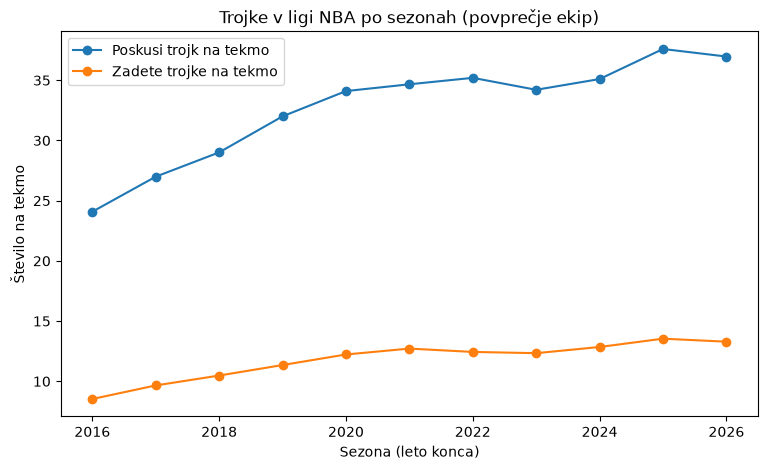

In [115]:
fig, os_trojke = plt.subplots(figsize=(9, 5))
po_sezonah["trojke_poskusi_na_tekmo"].plot(
    ax=os_trojke, marker="o", label="Poskusi trojk na tekmo"
)
po_sezonah["trojke_na_tekmo"].plot(
    ax=os_trojke, marker="o", label="Zadete trojke na tekmo"
)
os_trojke.set_title("Trojke v ligi NBA po sezonah (povprečje ekip)")
os_trojke.set_xlabel("Sezona (leto konca)")
os_trojke.set_ylabel("Število na tekmo")
os_trojke.legend()
plt.show()

trojke_poskusi_na_tekmo    154.0
trojke_na_tekmo            156.0
tocke_na_tekmo             113.0
Name: 2026, dtype: float64


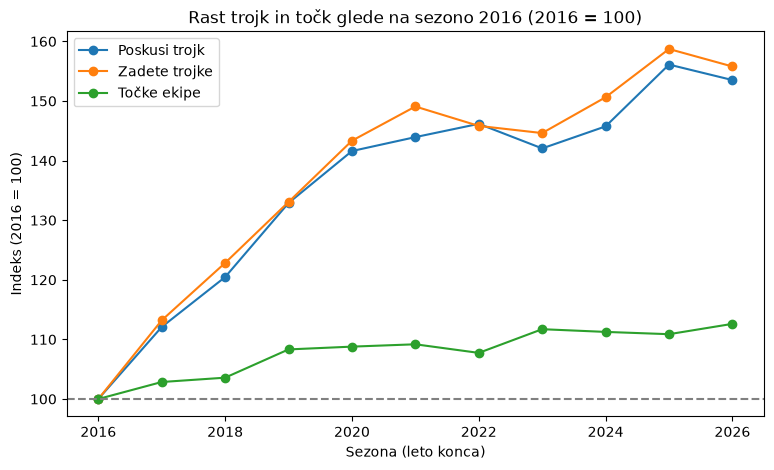

In [116]:
indeks = po_sezonah / po_sezonah.iloc[0] * 100
print(indeks.iloc[-1].round(0))

fig, os_indeks = plt.subplots(figsize=(9, 5))
indeks["trojke_poskusi_na_tekmo"].plot(
    ax=os_indeks, marker="o", label="Poskusi trojk"
)
indeks["trojke_na_tekmo"].plot(ax=os_indeks, marker="o", label="Zadete trojke")
indeks["tocke_na_tekmo"].plot(ax=os_indeks, marker="o", label="Točke ekipe")
os_indeks.axhline(100, color="gray", linestyle="--")
os_indeks.set_title("Rast trojk in točk glede na sezono 2016 (2016 = 100)")
os_indeks.set_xlabel("Sezona (leto konca)")
os_indeks.set_ylabel("Indeks (2016 = 100)")
os_indeks.legend()
plt.show()

Med sezonama 2016 in 2026 so se poskusi trojk na tekmo povečali z 24,1 na 37,0, zadete trojke pa z 8,5 na 13,3. Točke ekipe so zrasle manj (s 102,7 na 115,6), kar kaže tudi indeksni graf: trojke rastejo precej hitreje kot točke.

## 2. Ali so igralci v ligi starejši?

Drugo vprašanje primerja povprečno starost igralcev po sezonah. Starost je zapisana v tabeli `statistika`. V povprečje so vključeni le igralci z vsaj 500 odigranimi minutami v sezoni, ker igralci z zelo kratkim nastopom povprečja ne bi odražali. Prag 500 minut je izbran poljubno.

leto
2016    26.8
2017    26.6
2018    26.5
2019    26.3
2020    26.1
2021    26.2
2022    26.2
2023    26.1
2024    26.3
2025    26.3
2026    26.1
Name: starost, dtype: float64


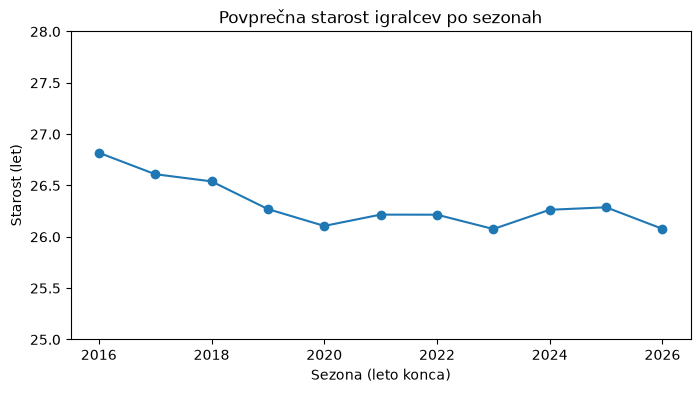

In [117]:
redni_500_minut = redni[redni["minute_skupaj"] >= 500]
starost_po_letih = redni_500_minut.groupby("leto")["starost"].mean()
print(starost_po_letih.round(1))

fig, os_starost = plt.subplots(figsize=(8, 4))
starost_po_letih.plot(ax=os_starost, marker="o")
os_starost.set_title("Povprečna starost igralcev po sezonah")
os_starost.set_xlabel("Sezona (leto konca)")
os_starost.set_ylabel("Starost (let)")
os_starost.set_ylim(25, 28)
plt.show()

Povprečna starost igralcev se je med sezonama 2016 in 2026 rahlo zmanjšala, z 26,8 na 26,1 leta, od sezone 2020 pa se ni več bistveno spreminjala. Liga torej ni starejša. Navpična os grafa se ne začne pri nič, zato je padec na grafu videti večji.

## 3. Kolikšen delež igralcev ni rojen v ZDA?

Tretje vprašanje obravnava državo rojstva. Za vsako sezono izračunam delež igralcev, ki niso rojeni v ZDA. Vsak igralec je v sezoni upoštevan le enkrat, tudi če je zamenjal ekipo, igralci brez podatka o državi pa so izpuščeni.

leto
2016    21.3
2017    23.7
2018    21.4
2019    22.3
2020    23.8
2021    23.1
2022    21.8
2023    22.7
2024    22.6
2025    22.7
2026    23.7
Name: tuji, dtype: float64


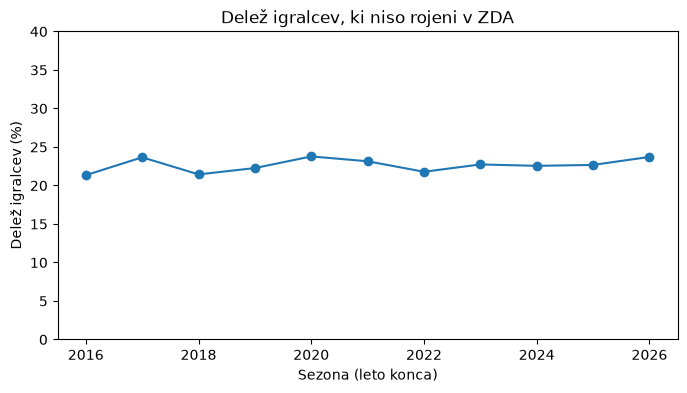

In [118]:
igralci_leta = (
    nastopi.drop_duplicates(["id_igralca", "leto"])
    .merge(igralci[["id", "drzava"]], left_on="id_igralca", right_on="id")
    .dropna(subset=["drzava"])
)
igralci_leta["tuji"] = igralci_leta["drzava"] != "US"
delez_tujih = igralci_leta.groupby("leto")["tuji"].mean() * 100
print(delez_tujih.round(1))

fig, os_tuji = plt.subplots(figsize=(8, 4))
delez_tujih.plot(ax=os_tuji, marker="o")
os_tuji.set_title("Delež igralcev, ki niso rojeni v ZDA")
os_tuji.set_xlabel("Sezona (leto konca)")
os_tuji.set_ylabel("Delež igralcev (%)")
os_tuji.set_ylim(0, 40)
plt.show()

Delež igralcev, ki niso rojeni v ZDA, se je v vseh sezonah gibal med 21,3 % in 23,8 %, brez jasnega trenda. Podatek je država rojstva, ne državljanstvo.

### Države rojstva
Delež tujih igralcev je v vseh sezonah podoben, zato pogledam še, iz katerih držav prihajajo. Prikazanih je deset držav z največ igralci v vseh sezonah skupaj, brez ZDA. Vsak igralec je upoštevan enkrat.

drzava
Kanada        44
Francija      38
Avstralija    27
Brazilija     12
Nemčija       12
Španija       12
Srbija        11
Argentina     10
Italija        8
Nigerija       8
Name: count, dtype: int64


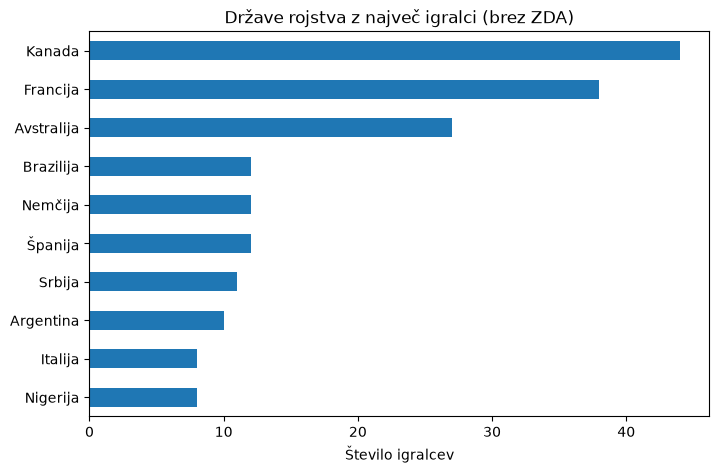

In [119]:
imena_drzav = {
    "CA": "Kanada", "FR": "Francija", "AU": "Avstralija", "BR": "Brazilija",
    "DE": "Nemčija", "ES": "Španija", "RS": "Srbija", "AR": "Argentina",
    "IT": "Italija", "NG": "Nigerija",
}

najpogostejse_drzave = (
    igralci[igralci["drzava"] != "US"]["drzava"].value_counts().head(10)
)
najpogostejse_drzave.index = najpogostejse_drzave.index.map(
    lambda oznaka: imena_drzav.get(oznaka, oznaka)
)
print(najpogostejse_drzave)

fig, os_drzave = plt.subplots(figsize=(8, 5))
najpogostejse_drzave.iloc[::-1].plot.barh(ax=os_drzave)
os_drzave.set_title("Države rojstva z največ igralci (brez ZDA)")
os_drzave.set_xlabel("Število igralcev")
os_drzave.set_ylabel("")
plt.show()

Med tujimi igralci je največ rojenih v Kanadi (44), Franciji (38) in Avstraliji (27). Prikazanih je deset držav z največ igralci.

# B. Ekipe

Drugi razdelek primerja ekipe: katere so bile v enajstih sezonah najuspešnejše, katere sezone so bile najboljše in kaj loči uspešne ekipe od neuspešnih. Primerjava temelji na tabeli `ekipe`, pri šestem vprašanju pa še na tabeli `po_ekipah` iz prvega razdelka.

Večina ekip v sezoni odigra 82 tekem, sezoni 2020 in 2021 pa sta bili krajši. Spodaj je prikazano povprečno število tekem ekipe v vsaki sezoni. Zaradi razlik v dolžini sezon pri povprečjih po ekipah uporabljam delež zmag in ne števila zmag.

leto
2016    82.0
2017    82.0
2018    82.0
2019    82.0
2020    70.6
2021    72.0
2022    82.0
2023    82.0
2024    82.0
2025    82.0
2026    82.0
dtype: float64


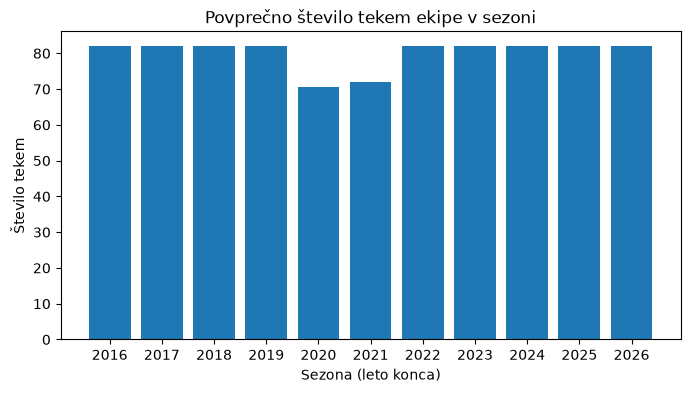

In [120]:
tekme_po_letih = (ekipe["zmage"] + ekipe["porazi"]).groupby(ekipe["leto"]).mean()
print(tekme_po_letih.round(1))

fig, os_tekme = plt.subplots(figsize=(8, 4))
os_tekme.bar(tekme_po_letih.index, tekme_po_letih.values)
os_tekme.set_xticks(tekme_po_letih.index)
os_tekme.set_title("Povprečno število tekem ekipe v sezoni")
os_tekme.set_xlabel("Sezona (leto konca)")
os_tekme.set_ylabel("Število tekem")
plt.show()

V sezonah 2020 in 2021 so ekipe odigrale manj kot 82 tekem (povprečno 70,6 oziroma 72,0), v vseh ostalih po 82. Zato v nadaljevanju uporabljam delež zmag in ne števila zmag.

## 4. Katere ekipe so najuspešnejše?

Četrto vprašanje primerja ekipe po povprečnem deležu zmag v sezonah od 2016 do 2026. Delež zmag je razmerje med zmagami in vsemi odigranimi tekmami, zato je primerljiv tudi pri krajših sezonah 2020 in 2021. Za vsako ekipo je izračunano povprečje enajstih sezon. Rdeča črta na grafu označuje 50 %, torej polovico zmag.

Ekipe so poimenovane po stanju v sezoni 2026, ker se nekatera imena in mesta skozi leta spreminjajo.

Najuspešnejših pet ekip (delež zmag, %):
kratica
Boston Celtics           65.4
Golden State Warriors    60.6
Denver Nuggets           59.9
Los Angeles Clippers     59.0
Milwaukee Bucks          59.0
Name: delez_zmag, dtype: float64
Najmanj uspešnih pet ekip (delež zmag, %):
kratica
Washington Wizards    39.0
Detroit Pistons       40.6
Brooklyn Nets         41.3
Charlotte Hornets     42.1
Orlando Magic         42.2
Name: delez_zmag, dtype: float64
Število ekip z deležem zmag pod 50 %: 17


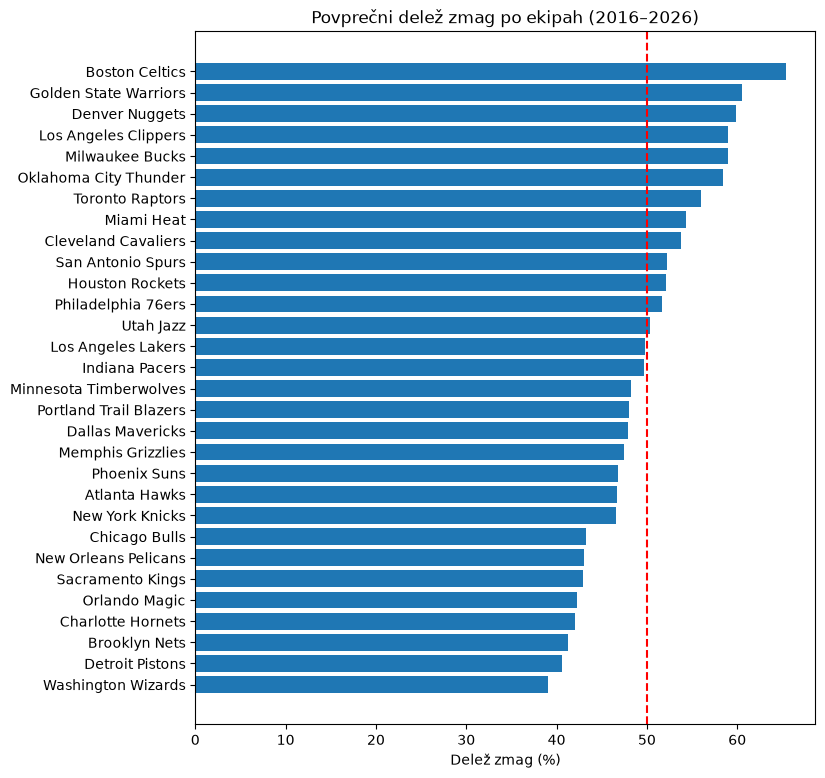

In [121]:
imena = ekipe[ekipe["leto"] == 2026].set_index("kratica")["ime"]
uspeh = ekipe.groupby("kratica")["delez_zmag"].mean().sort_values()
uspeh.index = uspeh.index.map(lambda kratica: imena.get(kratica, kratica))

print("Najuspešnejših pet ekip (delež zmag, %):")
print((uspeh.tail(5).iloc[::-1] * 100).round(1))
print("Najmanj uspešnih pet ekip (delež zmag, %):")
print((uspeh.head(5) * 100).round(1))
print("Število ekip z deležem zmag pod 50 %:", (uspeh < 0.5).sum())

fig, os_ekipe = plt.subplots(figsize=(8, 9))
os_ekipe.barh(uspeh.index, uspeh.values * 100)
os_ekipe.axvline(50, color="red", linestyle="--")
os_ekipe.set_title("Povprečni delež zmag po ekipah (2016–2026)")
os_ekipe.set_xlabel("Delež zmag (%)")
plt.show()

Povprečni delež zmag po ekipah je od 39,0 % (Washington Wizards) do 65,4 % (Boston Celtics). Nad 50 % je 13 ekip, pod 50 % pa 17. Rezultat je povprečje enajstih sezon in ne pokaže razvoja posamezne ekipe.

## 5. Katere sezone ekip so bile najboljše?

Prejšnje vprašanje je primerjalo povprečje enajstih sezon, to vprašanje pa posamezne sezone. Prikazanih je deset sezon z največ zmagami, vsaka je označena z imenom ekipe in letom. Primerjam število zmag in ne deleža, ker so sezone na vrhu lestvice po vsej verjetnosti polne, torej z 82 tekmami. Pri enakem številu zmag se prikaže poljubna izmed enakovrednih ekip.

                  ime  leto  zmage  porazi
Golden State Warriors  2016     73       9
Oklahoma City Thunder  2025     68      14
    San Antonio Spurs  2016     67      15
Golden State Warriors  2017     67      15
      Houston Rockets  2018     65      17
         Phoenix Suns  2022     64      18
       Boston Celtics  2024     64      18
  Cleveland Cavaliers  2025     64      18
Oklahoma City Thunder  2026     64      18
    San Antonio Spurs  2026     62      20


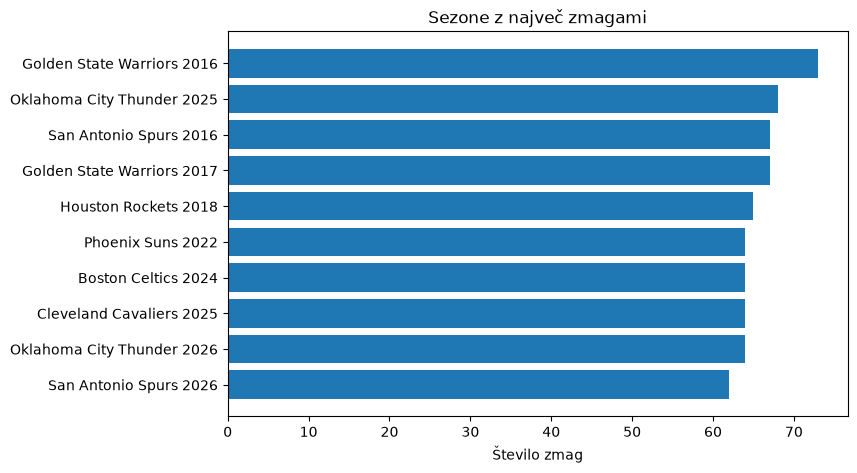

In [122]:
najboljse = ekipe.nlargest(10, "zmage").iloc[::-1]
oznake_sezon = najboljse["ime"] + " " + najboljse["leto"].astype(str)
print(najboljse[["ime", "leto", "zmage", "porazi"]].iloc[::-1].to_string(index=False))

fig, os_naj = plt.subplots(figsize=(8, 5))
os_naj.barh(oznake_sezon, najboljse["zmage"])
os_naj.set_title("Sezone z največ zmagami")
os_naj.set_xlabel("Število zmag")
plt.show()

Najboljša sezona je sezona 2016 Golden State Warriors s 73 zmagami in 9 porazi. Sledijo Oklahoma City Thunder 2025 (68 zmag) ter San Antonio Spurs 2016 in Golden State Warriors 2017 (obe 67 zmag). Vseh deset sezon ima 82 tekem, zmage so med 62 in 73.

## 6. Kaj loči uspešne ekipe?

Šesto vprašanje primerja delež zmag s tremi merami: razliko med doseženimi in prejetimi točkami na tekmo, številom zadetih trojk in številom poskusov trojk. Uporabljena je tabela `po_ekipah` iz prvega vprašanja, kjer je vsaka vrstica ena ekipa v eni sezoni.

Ker so v poznejših sezonah vse ekipe metale več trojk, je od vsake ekipe odštet povprečje njene sezone. Tako so primerjane ekipe med seboj in ne sezone. Povezava je izražena s korelacijo, ki ima vrednosti od −1 do 1: večja ko je, bolj skupaj se gibljeta količini.

trojke_poskusi_na_tekmo_rel    0.17
trojke_na_tekmo_rel            0.36
razlika_tock                   0.97
Name: delez_zmag, dtype: float64


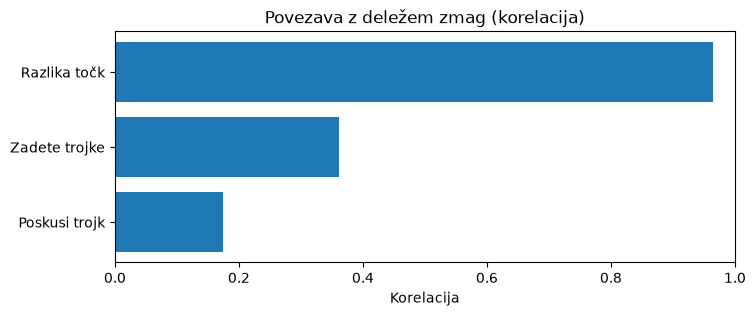

In [123]:
po_ekipah["razlika_tock"] = (
    po_ekipah["tocke_na_tekmo"] - po_ekipah["prejete_tocke_na_tekmo"]
)

# Odstopanje od povprečja sezone, da trend skozi leta ne pokvari primerjave.
for stolpec in ["trojke_poskusi_na_tekmo", "trojke_na_tekmo"]:
    povprecje_sezone = po_ekipah.groupby("leto")[stolpec].transform("mean")
    po_ekipah[stolpec + "_rel"] = po_ekipah[stolpec] - povprecje_sezone

primerjava = [
    "trojke_poskusi_na_tekmo_rel",
    "trojke_na_tekmo_rel",
    "razlika_tock",
]
korelacije = (
    po_ekipah[primerjava + ["delez_zmag"]]
    .corr()["delez_zmag"]
    .drop("delez_zmag")
)
print(korelacije.round(2))

fig, os_kor = plt.subplots(figsize=(8, 3))
os_kor.barh(["Poskusi trojk", "Zadete trojke", "Razlika točk"], korelacije.values)
os_kor.set_xlim(0, 1)
os_kor.set_title("Povezava z deležem zmag (korelacija)")
os_kor.set_xlabel("Korelacija")
plt.show()

Delež zmag je najmočneje povezan z razliko med doseženimi in prejetimi točkami (0,97), kar je pričakovano. Zadete trojke imajo zmerno povezavo (0,36), poskusi trojk pa šibko (0,17). Korelacija ne dokazuje vzroka.

# C. Igralci

Tretji razdelek obravnava posamezne igralce: najboljše točkovalce, vodilne po točkah, skokih in asistencah, vpliv pozicije, višino ter fakultete.

## 7. Kdo so najboljši točkovalci?

Igralci so primerjani po točkah na 36 minut, da igralci z več igralnega časa niso v prednosti. Za vsakega igralca so točke in minute seštete čez vse sezone in ekipe, nato je izračunano razmerje, pomnoženo s 36. Število 36 je običajna izbira v analizi košarke, ker je približno igralni čas prvega igralca. Vrstni red igralcev bi bil pri drugačnem številu minut enak.

Upoštevani so le igralci z vsaj 5000 minutami, ker bi sicer zmagali igralci z le nekaj tekmami in naključno visokim povprečjem. Tabela `skupaj`, v kateri so vsote po igralcih, se uporabi tudi pri 8. vprašanju.

In [124]:
skupaj = (
    redni.groupby("id_igralca")[[
        "minute_skupaj", "tocke_skupaj", "skoki_skupaj", "asistence_skupaj", "tekme",
    ]]
    .sum()
    .reset_index()
    .merge(igralci[["id", "ime"]], left_on="id_igralca", right_on="id")
)
skupaj["tocke_na_36"] = skupaj["tocke_skupaj"] / skupaj["minute_skupaj"] * 36

dovolj_minut = skupaj[skupaj["minute_skupaj"] >= 5000]
top10 = dovolj_minut.nlargest(10, "tocke_na_36")
print(top10[["ime", "tekme", "tocke_na_36"]].round(1))

                          ime  tekme  tocke_na_36
410               Joel Embiid    490         31.2
365               Luka Dončić    514         30.0
323             Stephen Curry    653         29.5
38      Giannis Antetokounmpo    737         29.0
1462        Victor Wembanyama    181         27.7
1514          Zion Williamson    276         27.7
492   Shai Gilgeous-Alexander    530         27.5
389              Kevin Durant    632         27.4
827            Damian Lillard    654         26.9
817             Kawhi Leonard    546         26.8


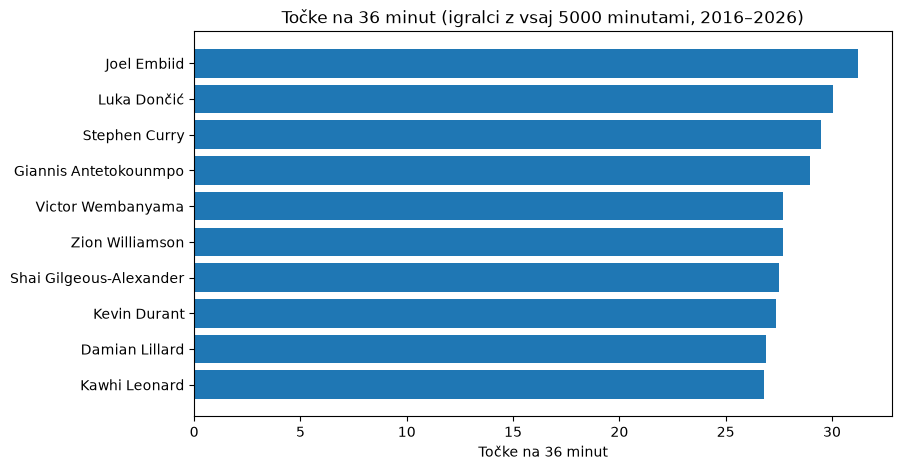

In [125]:
fig, os_top = plt.subplots(figsize=(9, 5))
os_top.barh(top10["ime"].iloc[::-1], top10["tocke_na_36"].iloc[::-1])
os_top.set_title("Točke na 36 minut (igralci z vsaj 5000 minutami, 2016–2026)")
os_top.set_xlabel("Točke na 36 minut")
plt.show()

Največ točk na 36 minut ima Joel Embiid (31,2), sledita Luka Dončić (30,0) in Stephen Curry (29,5). Victor Wembanyama (181 tekem) in Zion Williamson (276 tekem) imata bistveno manj tekem kot drugi, zato je njuno povprečje manj zanesljivo.

## 8. Kdo je dosegel največ točk, skokov in asistenc?

Osmo vprašanje prikazuje deset igralcev z največ skupnimi točkami, skoki in asistencami v rednem delu sezon od 2016 do 2026. Skupne vrednosti so izračunane kot povprečje na tekmo krat število tekem, zato so približne. Zajete so le sezone iz podatkov, ne cela kariera igralcev, zato igralec, ki je začel pred letom 2016 ali igral po letu 2026, nima prikazanih vseh točk.

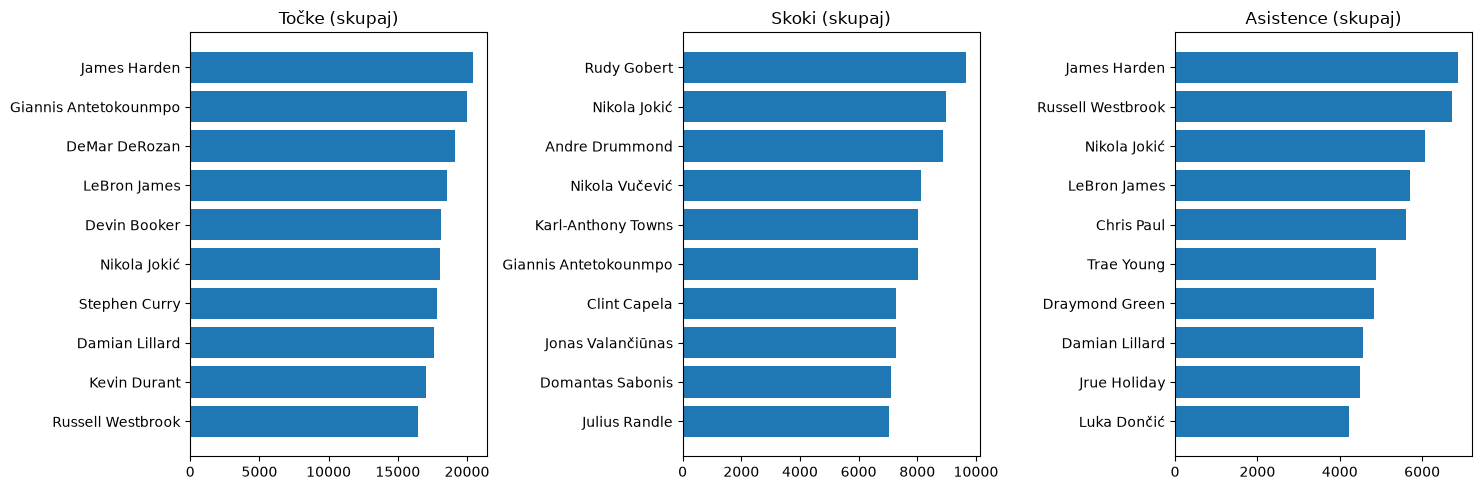

In [126]:
vodilni = {
    "Točke": "tocke_skupaj",
    "Skoki": "skoki_skupaj",
    "Asistence": "asistence_skupaj",
}

fig, osi = plt.subplots(1, 3, figsize=(15, 5))
for os_, (naslov, stolpec) in zip(osi, vodilni.items()):
    top = skupaj.nlargest(10, stolpec).iloc[::-1]
    os_.barh(top["ime"], top[stolpec])
    os_.set_title(f"{naslov} (skupaj)")
plt.tight_layout()
plt.show()

Največ točk in asistenc je dosegel James Harden, največ skokov pa Rudy Gobert. Nikola Jokić je med prvimi tremi pri skokih in asistencah.

## 9. Ali pozicija vpliva na skoke in asistence?

Deveto vprašanje primerja skoke in asistence na 36 minut med petimi pozicijami: PG (organizator igre), SG (branilec), SF (krilo), PF (visoko krilo) in C (center). Pozicija igralca je v tabeli `nastopi` in je zapisana za vsako sezono posebej, zato je pred primerjavo združena s statistiko. Upoštevane so le sezone igralcev z vsaj 500 minutami, ker so pri manj minutah povprečja preveč naključna.

Vsaka škatla na grafu zajema srednjo polovico igralcev, črta v njej je mediana (srednji igralec), posamezne pike pa so izstopajoče vrednosti.

In [127]:
pozicije = redni.merge(
    nastopi[["id_igralca", "kratica", "leto", "pozicija"]],
    on=["id_igralca", "kratica", "leto"],
)
pozicije = pozicije[pozicije["minute_skupaj"] >= 500].copy()
pozicije["skoki_36"] = pozicije["skoki"] / pozicije["minute"] * 36
pozicije["asistence_36"] = pozicije["asistence"] / pozicije["minute"] * 36

print(pozicije["pozicija"].value_counts())

pozicija
SG    967
PG    799
PF    791
C     767
SF    741
Name: count, dtype: int64


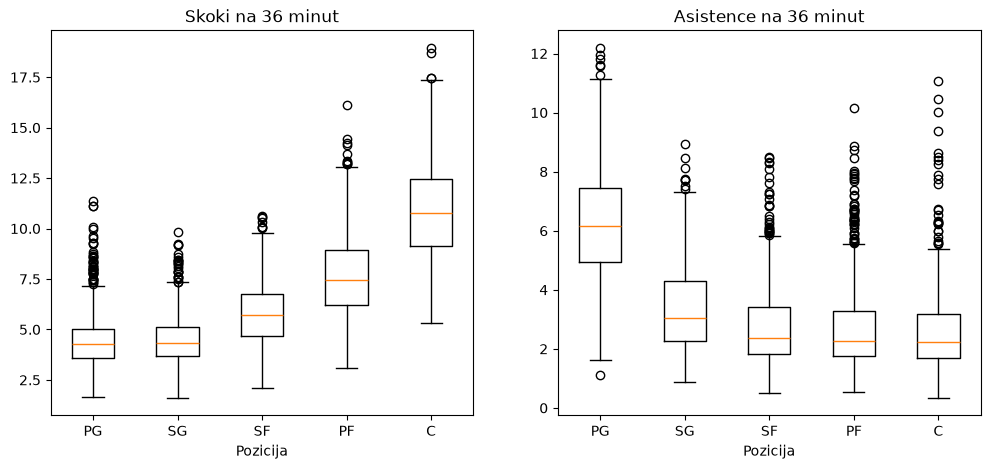

          skoki_36  asistence_36
pozicija                        
PG             4.3           6.2
SG             4.3           3.1
SF             5.7           2.4
PF             7.5           2.3
C             10.8           2.2


In [128]:
vrstni_red = ["PG", "SG", "SF", "PF", "C"]

fig, osi = plt.subplots(1, 2, figsize=(12, 5))
for os_, stolpec, naslov in zip(
    osi, ["skoki_36", "asistence_36"], ["Skoki na 36 minut", "Asistence na 36 minut"]
):
    podatki = [
        pozicije.loc[pozicije["pozicija"] == poz, stolpec] for poz in vrstni_red
    ]
    os_.boxplot(podatki)
    os_.set_xticks(range(1, 6), labels=vrstni_red)
    os_.set_title(naslov)
    os_.set_xlabel("Pozicija")
plt.show()

mediane = pozicije.groupby("pozicija")[["skoki_36", "asistence_36"]].median()
print(mediane.loc[vrstni_red].round(1))

Centri imajo največ skokov (mediana 10,8 na 36 minut), organizatorji igre pa največ asistenc (6,2). Pozicija torej močno vpliva na obe statistiki.

## 10. Kako visoki so igralci?

Deseto vprašanje obravnava višino igralcev. Višina je v tabeli `nastopi` preračunana iz čevljev in palcev v centimetre. Vsak igralec je v sezoni upoštevan le enkrat, tudi če je zamenjal ekipo. Prvi graf (histogram) kaže, koliko igralskih sezon spada v posamezen razpon višine, drugi pa primerja povprečno višino po pozicijah.

Povprečna višina: 199.3 cm
Najnižji: 170 cm; najvišji: 229 cm


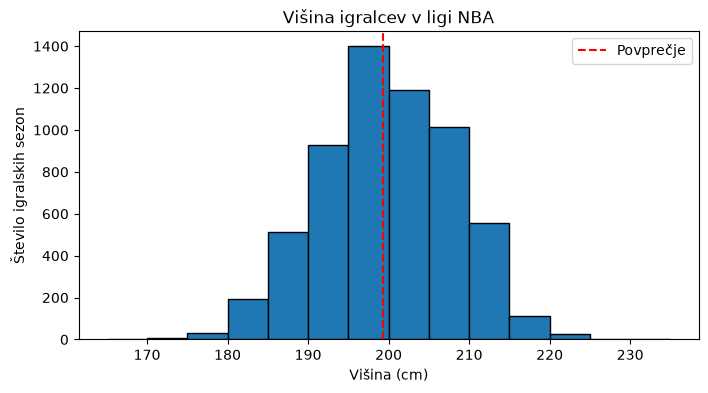

In [129]:
visine = nastopi.dropna(subset=["visina_cm"]).drop_duplicates(["id_igralca", "leto"])
povprecna_visina = visine["visina_cm"].mean()
print("Povprečna višina:", round(povprecna_visina, 1), "cm")
print(
    "Najnižji:", visine["visina_cm"].min(), "cm; najvišji:",
    visine["visina_cm"].max(), "cm",
)

fig, os_vis = plt.subplots(figsize=(8, 4))
os_vis.hist(visine["visina_cm"], bins=range(165, 240, 5), edgecolor="black")
os_vis.axvline(povprecna_visina, color="red", linestyle="--", label="Povprečje")
os_vis.set_title("Višina igralcev v ligi NBA")
os_vis.set_xlabel("Višina (cm)")
os_vis.set_ylabel("Število igralskih sezon")
os_vis.legend()
plt.show()

pozicija
PG    188.7
SG    194.4
SF    200.2
PF    204.3
C     209.8
Name: visina_cm, dtype: float64


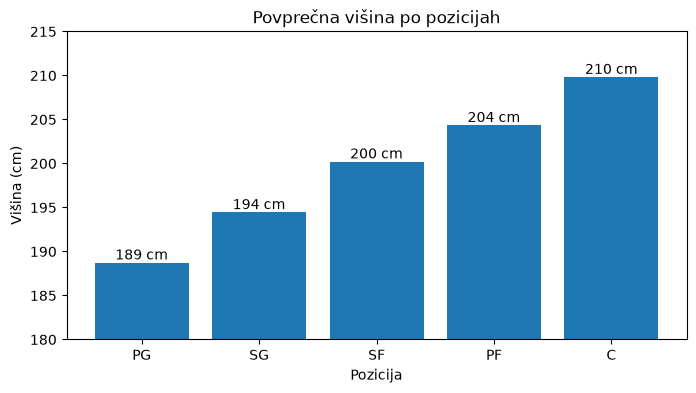

In [130]:
visina_po_poz = visine.groupby("pozicija")["visina_cm"].mean().loc[vrstni_red]
print(visina_po_poz.round(1))

fig, os_poz = plt.subplots(figsize=(8, 4))
stolpci_vis = os_poz.bar(visina_po_poz.index, visina_po_poz.values)
os_poz.bar_label(stolpci_vis, fmt="%.0f cm")
os_poz.set_ylim(180, 215)
os_poz.set_title("Povprečna višina po pozicijah")
os_poz.set_xlabel("Pozicija")
os_poz.set_ylabel("Višina (cm)")
plt.show()

Povprečna višina igralcev je 199,3 cm (od 170 do 229 cm) in narašča od organizatorjev igre (188,7 cm) do centrov (209,8 cm). Navpična os drugega grafa se začne pri 180 cm, zato so razlike na grafu videti večje.

## 11. Iz katerih fakultet prihajajo igralci?

Zadnje vprašanje prikazuje deset fakultet z največ igralci v ligi. Igralec, ki je obiskoval dve fakulteti, je upoštevan pri obeh. Če podatka o fakulteti ni, je polje prazno: to velja predvsem za igralce, ki so prišli iz tujih klubov ali neposredno iz srednje šole, ne nujno, da igralec ni študiral.

fakulteta
Kentucky    69
Duke        61
Kansas      38
UNC         37
Arizona     33
UCLA        32
Michigan    28
Gonzaga     26
Florida     24
Baylor      23
Name: count, dtype: int64
Delež igralcev brez podatka o fakulteti: 14.0 %


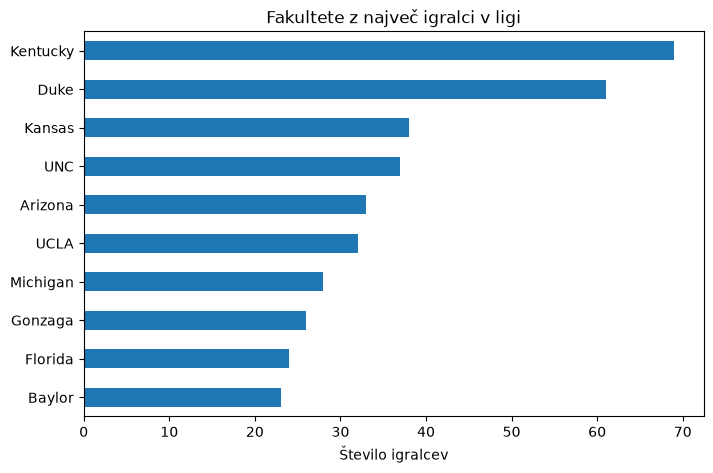

In [131]:
fakultete = (
    igralci["fakulteta"].dropna().str.split(", ").explode().value_counts().head(10)
)
print(fakultete)
print(
    "Delež igralcev brez podatka o fakulteti:",
    round(igralci["fakulteta"].isna().mean() * 100, 1), "%",
)

fig, os_fak = plt.subplots(figsize=(8, 5))
fakultete.iloc[::-1].plot.barh(ax=os_fak)
os_fak.set_title("Fakultete z največ igralci v ligi")
os_fak.set_xlabel("Število igralcev")
os_fak.set_ylabel("")
plt.show()

Največ igralcev je obiskovalo fakulteto Kentucky (69), sledita Duke (61) in Kansas (38). Za 14,0 % igralcev podatka o fakulteti ni.

# Zaključek

**Kako se je liga spreminjala.** Med sezonama 2016 in 2026 so ekipe bistveno več metale trojk in jih več zadele, točke ekipe pa so zrasle precej manj. Povprečna starost igralcev se je rahlo zmanjšala, delež tujih igralcev pa je ostal okoli 22 %.

**Ekipe.** Najuspešnejša ekipa v povprečju so Boston Celtics, najboljša posamezna sezona pa je sezona 2016 Golden State Warriors (73 zmag). Delež zmag je najmočneje povezan z razliko točk, zadete trojke imajo zmerno povezavo.

**Igralci.** Najboljši točkovalec na 36 minut je Joel Embiid. Pozicija močno vpliva na skoke, asistence in višino. Največ igralcev prihaja s fakultet Kentucky in Duke.

**Omejitve.** Podatki zajemajo enajst sezon, analiza obravnava samo redni del sezone, vsote so zaradi zaokroževanja približne, povezava med količinama pa ne dokazuje vzroka.